# ABIDE Data Exploration

## Dataset Overview

- **Dataset:** ABIDE I (Autism Brain Imaging Data Exchange I)
- **Participants:** Autism Spectrum Disorder (ASD) and typically developing controls
- **Available data:** resting-state fMRI and phenotypic information
- **Local phenotypic table:** 1,112 participants and 106 columns
- **Phenotypic fields:**
  - diagnostic group
  - age and sex
  - handedness
  - acquisition site
  - IQ measurements
  - autism-specific assessments
  - imaging quality-control variables
- **Selected fMRI derivative:** CC200 parcellation
- **Data representation per subject:**
  - rows = scan time points
  - columns = 200 regions of interest (ROIs)
  - each column = BOLD signal for one ROI over time
- **Inspected example:** 196 time points x 200 ROIs

In [1]:
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", message="IProgress not found.*")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from nilearn import datasets

sns.set_theme(style="whitegrid")

## Load one preprocessed ABIDE subject

- Load the subject's phenotypic data
- Load the subject's CC200 regional time series

In [2]:
N_SUBJECTS = 1
if (Path.cwd() / "abide_gnn").is_dir():
    PROJECT_ROOT = Path.cwd()
elif (Path.cwd().parent / "abide_gnn").is_dir():
    PROJECT_ROOT = Path.cwd().parent
else:
    raise FileNotFoundError(
        "Open this notebook from the repository or notebooks directory."
    )
ABIDE_DATA_DIR = PROJECT_ROOT / "data" / "abide_pcp"

abide = datasets.fetch_abide_pcp(
    data_dir=ABIDE_DATA_DIR,
    n_subjects=N_SUBJECTS,
    pipeline="cpac",
    band_pass_filtering=True,
    global_signal_regression=False,
    derivatives=["rois_cc200"],
    quality_checked=True,
    verbose=0,
)
print(
    "[fetch_abide_pcp] Dataset directory found: "
    f"{ABIDE_DATA_DIR.relative_to(PROJECT_ROOT) / 'ABIDE_pcp'}"
)

phenotypic = abide.phenotypic
cc200_time_series = abide.rois_cc200

[fetch_abide_pcp] Dataset directory found: data\abide_pcp\ABIDE_pcp


## Cohort Summary

- **Diagnostic encoding:** `DX_GROUP` — `1 = ASD`, `2 = control`
- **Sex encoding:** `SEX` — `1 = male`, `2 = female`

In [3]:
phenotypic_path = ABIDE_DATA_DIR / "ABIDE_pcp" / "Phenotypic_V1_0b_preprocessed1.csv"
phenotypic_all = pd.read_csv(phenotypic_path, na_values=[-9999, "-9999"])

diagnostic_counts = (
    phenotypic_all["DX_GROUP"]
    .map({1: "ASD", 2: "Control"})
    .value_counts()
    .reindex(["ASD", "Control"])
)
sex_counts = (
    phenotypic_all["SEX"]
    .map({1: "Male", 2: "Female"})
    .value_counts()
    .reindex(["Male", "Female"])
)
age = phenotypic_all["AGE_AT_SCAN"]

print(f"Number of participants: {len(phenotypic_all):,}")
print(f"Number of columns: {phenotypic_all.shape[1]}")
print("\nDiagnostic groups:")
print(diagnostic_counts.to_string())
print(f"\nNumber of acquisition sites: {phenotypic_all['SITE_ID'].nunique()}")
print("\nAge (years):")
print(f"Mean: {age.mean():.2f}")
print(f"Minimum: {age.min():.2f}")
print(f"Maximum: {age.max():.2f}")
print("\nSex:")
print(sex_counts.to_string())

Number of participants: 1,112
Number of columns: 106

Diagnostic groups:
DX_GROUP
ASD        539
Control    573

Number of acquisition sites: 20

Age (years):
Mean: 17.05
Minimum: 6.47
Maximum: 64.00

Sex:
SEX
Male      948
Female    164


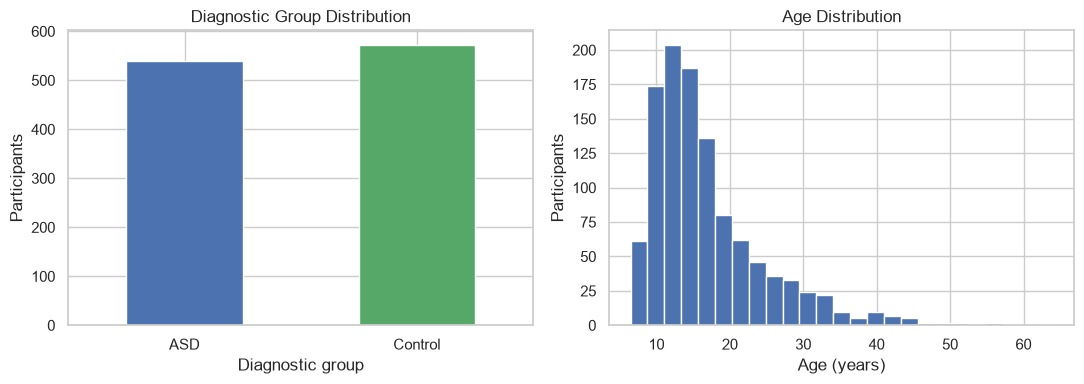

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

diagnostic_counts.plot(
    kind="bar",
    ax=axes[0],
    color=["#4C72B0", "#55A868"],
    rot=0,
    title="Diagnostic Group Distribution",
)
axes[0].set_xlabel("Diagnostic group")
axes[0].set_ylabel("Participants")

axes[1].hist(age.dropna(), bins=25, color="#4C72B0", edgecolor="white")
axes[1].set_title("Age Distribution")
axes[1].set_xlabel("Age (years)")
axes[1].set_ylabel("Participants")

plt.tight_layout()
plt.show()

## Phenotypic Data

- **Missing-value codes:** `NaN`, `-9999`

- **IDs and basic information (13 features):**
  - `i`, `Unnamed: 0`, `X`: old CSV indexes; ignore
  - `SUB_ID`, `subject`, `FILE_ID`: participant/file IDs
  - `SITE_ID`: scanning site, e.g. `PITT`
  - `DX_GROUP`: `1 = autism`, `2 = control`
  - `DSM_IV_TR`: `0 = control`, `1 = autism`, `2 = Asperger`, `3 = PDD-NOS`, `4 = Asperger/PDD-NOS`
  - `AGE_AT_SCAN`: age in years
  - `SEX`: `1 = male`, `2 = female`
  - handedness: category and score from `-100` to `100`

- **IQ (6 features):**
  - `FIQ`, `VIQ`, `PIQ`: full-scale, verbal, and nonverbal IQ
  - test types: `WASI`, `WISC`, `WAIS`, etc.

- **Autism assessments (24 features):**
  - `ADI_R_*` (5): social, communication, repetitive behaviour, onset, reliability
  - `ADOS_*` (10): observed behaviour, total, module, severity
  - `SRS_*` (7): social awareness, cognition, communication, motivation, mannerisms
  - `SCQ_TOTAL`, `AQ_TOTAL`: questionnaire totals

- **Medication and other diagnoses (4 features):**
  - `COMORBIDITY`
  - medication status/name
  - stimulants stopped before scan: `0 = no`, `1 = yes`

- **`VINELAND_*` (15 features):**
  - communication, daily living, social skills, coping, adaptive behaviour

- **`WISC_IV_*` (14 features):**
  - reasoning, working memory, processing speed, cognitive subtests

- **Scan information (3 features):**
  - eyes: `1 = open`, `2 = closed`
  - age at anatomical scan
  - BMI

- **Image quality (16 features):**
  - `anat_*` (6): contrast, noise, smoothness, artifacts
  - `func_*` (10): signal quality, outliers, head motion

- **Manual quality control (10 features):**
  - `qc_*`: human ratings/notes — `OK`, `maybe`, `fail`

- **Original sample (1 feature):**
  - `SUB_IN_SMP`: `0 = no`, `1 = yes`

In [5]:
print("\nPhenotypic data of one subject:")
phenotypic.head()


Phenotypic data of one subject:


,i,Unnamed: 0,SUB_ID,X,subject,SITE_ID,FILE_ID,DX_GROUP,DSM_IV_TR,AGE_AT_SCAN,...,qc_notes_rater_1,qc_anat_rater_2,qc_anat_notes_rater_2,qc_func_rater_2,qc_func_notes_rater_2,qc_anat_rater_3,qc_anat_notes_rater_3,qc_func_rater_3,qc_func_notes_rater_3,SUB_IN_SMP
1,1,2,50003,2,50003,PITT,Pitt_0050003,1,1,24.45,...,NaN,OK,NaN,OK,NaN,OK,NaN,OK,NaN,1


## Inspect the CC200 Regional Time Series

- **Rows:** scan time points
- **Columns:** 200 CC200 brain regions

In [6]:
time_series_source = cc200_time_series[0]

time_series = np.asarray(time_series_source)

print(f"Time-series shape: {time_series.shape}")
print(f"Time points: {time_series.shape[0]}")
print(f"Brain regions: {time_series.shape[1]}")

time_series

Time-series shape: (196, 200)
Time points: 196
Brain regions: 200


array([[  24.560342,  -18.407722,   38.447947, ...,    7.148534,
         -16.70126 ,   -9.040049],
       [  12.432386,  -24.225554,   32.72212 , ...,    6.915863,
         -18.816158,  -16.079462],
       [ -15.628296,  -26.657624,    4.821955, ...,    1.262588,
         -17.565622,  -29.46237 ],
       ...,
       [ -78.053982,  -28.795672, -114.368604, ...,  -34.754758,
         -96.55319 ,  -78.052758],
       [ -46.00144 ,  -16.829028,  -64.951275, ...,  -17.228399,
         -49.759665,  -57.640293],
       [ -11.677131,   -9.211697,  -21.498266, ...,    0.149923,
          -8.384009,  -29.650198]], shape=(196, 200))

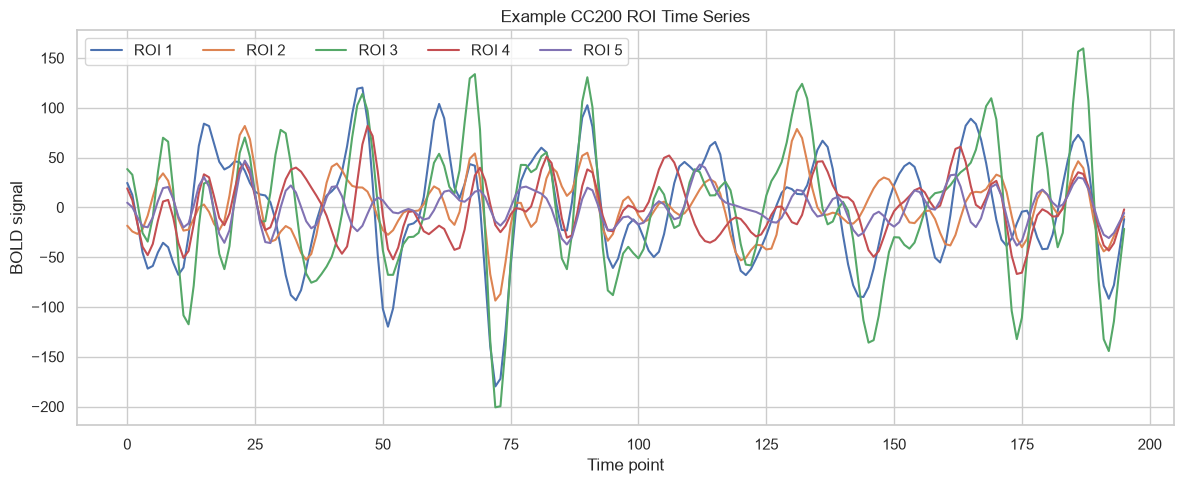

In [7]:
plt.figure(figsize=(12, 5))

for roi_index in range(5):
    plt.plot(time_series[:, roi_index], label=f"ROI {roi_index + 1}")

plt.xlabel("Time point")
plt.ylabel("BOLD signal")
plt.title("Example CC200 ROI Time Series")
plt.legend(ncol=5)
plt.tight_layout()
plt.show()

## Data Available for Graph Construction

- **Available:** main information needed to construct one brain graph per subject later
- **Not calculated here:** connectivity matrices and graph edges

### Nodes

- **Atlas:** CC200
- **Consistent regions:** 200 ROIs per subject
- **Graph interpretation:**
  - one subject = one graph
  - one ROI = one vertex

### ROI-level Information

- **Available for each ROI:** BOLD time series
- **Possible future vertex representations:**
  - time-series statistics
  - embeddings learned with a temporal model, such as a small 1D CNN
  - ROI identity
  - ROI spatial information
  - combinations of these features

### Relationships Between ROIs

- **Available input:** all ROI time series for each subject
- **Possible future edge approaches:**
  - functional connectivity followed by a threshold
  - fixed-density graphs
  - top-k neighborhood graphs

### Graph-level Information and Target

- **Classification target:** `DX_GROUP`
- **Available subject-level variables:**
  - diagnosis
  - age
  - sex
  - handedness
  - acquisition site
- **Possible future use:** additional graph-level features
- **Factors to consider:** missingness and possible confounding effects